# Task 1: Computer Vision using CNN Models

**Part A** — Traditional (AlexNet-style) CNN baseline on CIFAR-10

**Part B** — Customized CNN designed to measurably beat the Part A baseline

Both parts use the **same fixed random seed and the same train/validation/test split**, and the **same training-epoch budget** (Part B states clearly if it deviates), so the comparison between them is fair.

# Part A: Traditional CNN Model

**Objective:** Implement a traditional CNN using TensorFlow and Keras to classify images from the CIFAR-10 dataset, establishing a clean performance baseline.

**Success threshold:** the traditional CNN should reach **≥ 70% test accuracy**.

This is deliberately a **clean baseline**: no data augmentation, no batch normalization, no learning-rate scheduling — so that the effect of each of those techniques can be measured cleanly when they're introduced in Part B.

## Step 1 | Imports and Reproducibility Setup

In [1]:
pip install tensorflow

In [3]:
import os
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score
)


os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

# ---- Fixed random seed, used for BOTH Part A and Part B ----
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print('TensorFlow version:', tf.__version__)
print('Fixed seed:', SEED)

TensorFlow version: 2.20.0
Fixed seed: 42


## Step 2 | Load and Explore CIFAR-10

In [4]:
import tensorflow as tf
print('Is GPU available:', tf.config.list_physical_devices('GPU'))

Is GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

print('Full training set:', X_train_full.shape, y_train_full.shape)
print('Test set         :', X_test.shape, y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1750s 10us/step
Full training set: (50000, 32, 32, 3) (50000, 1)
Test set         : (10000, 32, 32, 3) (10000, 1)


### Fixed Train/Validation/Test Split

A single split, using `SEED = 42` and stratified by class, is created here and **reused unchanged in Part B** so both models are trained and evaluated on identical data.


In [6]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full,
    test_size=0.10,
    random_state=SEED,
    stratify=y_train_full
)

print('Train Images Shape:      ', X_train.shape)
print('Validation Images Shape: ', X_valid.shape)
print('Test Images Shape:       ', X_test.shape)

Train Images Shape:       (45000, 32, 32, 3)
Validation Images Shape:  (5000, 32, 32, 3)
Test Images Shape:        (10000, 32, 32, 3)


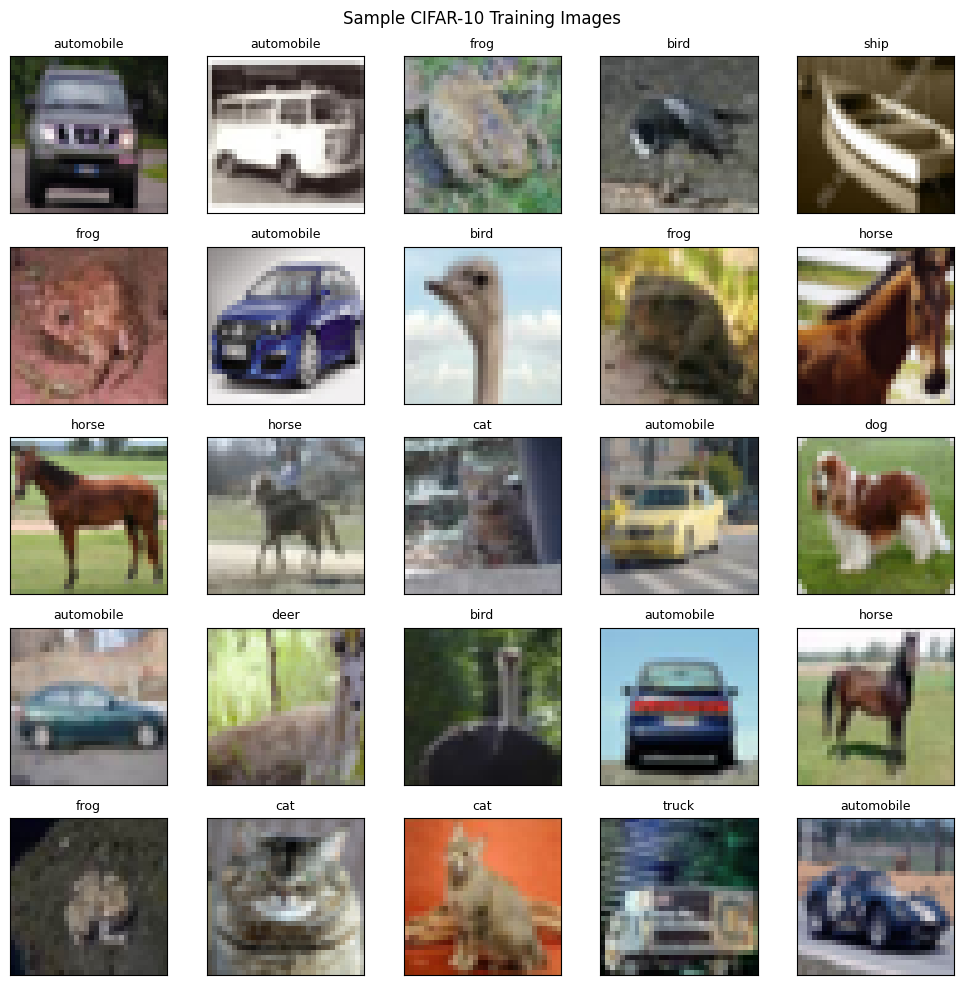

In [7]:
# Quick visual sanity check of the data
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([]); plt.yticks([]); plt.grid(False)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=9)
plt.suptitle('Sample CIFAR-10 Training Images')
plt.tight_layout()
plt.show()

## Step 3 | Preprocessing

### 3.1 Normalize Pixel Values

Pixel values are cast to `float32` and rescaled from `[0, 255]` to `[0, 1]`. The same normalization is reused in Part B for a fair comparison.

In [8]:
X_train = X_train.astype('float32') / 255.0
X_valid = X_valid.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

print('Pixel value range after normalization: [%.2f, %.2f]' % (X_train.min(), X_train.max()))

Pixel value range after normalization: [0.00, 1.00]


### 3.2 One-Hot Encode Labels

In [9]:
y_train_cat = to_categorical(y_train, 10)
y_valid_cat = to_categorical(y_valid, 10)
y_test_cat  = to_categorical(y_test, 10)

print(y_train_cat.shape, y_valid_cat.shape, y_test_cat.shape)

(45000, 10) (5000, 10) (10000, 10)


### 3.3 No Data Augmentation in Part A

Per the requirements, Part A is kept as a **clean baseline with no data augmentation**, so its effect can be measured cleanly when it's introduced in Part B.

## Step 4 | Define the AlexNet-style CNN Architecture

The classic **AlexNet** was designed for 227×227 inputs with 96/256/384 filters and an 11×11 first-layer kernel with stride 4 — copying that directly onto 32×32 CIFAR-10 images causes dimension mismatches (the spatial size would collapse to nothing after a couple of layers). The architecture below **adapts** AlexNet's core ideas instead of copying it verbatim:

- Increasing filter counts (**64 → 128 → 256**), as suggested by the task.
- Larger kernels early on (5×5) shrinking to 3×3 later, echoing AlexNet's   large-kernel-then-smaller-kernel pattern, but scaled down so 32×32 inputs survive   three pooling stages (32→16→8→4) instead of collapsing.
- Stride-1 convolutions with `padding='same'` throughout (AlexNet's aggressive stride-4   first layer isn't usable at this input resolution) — pooling layers do the   downsampling instead.
- Large fully-connected layers with dropout (0.5), matching AlexNet's use of dropout   only in the FC head — no batch normalization, no per-block dropout, no L2: those are   deliberately left for the Part B customization so their effect can be isolated.

In [10]:
def build_traditional_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = Sequential(name='AlexNet_style_traditional_CNN')

    # Block 1: 64 filters, 5x5 (adapted from AlexNet's large first-layer kernel)
    model.add(Conv2D(64, (5, 5), padding='same', activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))          # 32x32 -> 16x16

    # Block 2: 128 filters, 5x5
    model.add(Conv2D(128, (5, 5), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))          # 16x16 -> 8x8

    # Block 3: 256 filters, 3x3 x2 (mirrors AlexNet's stacked conv layers before its last pool)
    model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
    model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))          # 8x8 -> 4x4

    # Fully connected head (AlexNet-style large FC layers + dropout)
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    return model

traditional_model = build_traditional_cnn()
traditional_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "AlexNet_style_traditional_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,326,602 (12.69 MB)

 Trainable params: 3,326,602 (12.69 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
traditional_param_count = traditional_model.count_params()
print('Total parameters (Traditional CNN):', f'{traditional_param_count:,}')

Total parameters (Traditional CNN): 3,326,602


## Step 4b | Architecture Diagram (Traditional CNN)

A visual diagram of the traditional (AlexNet-style) CNN's layer stack, generated directly from the model object so it always matches the actual code above.

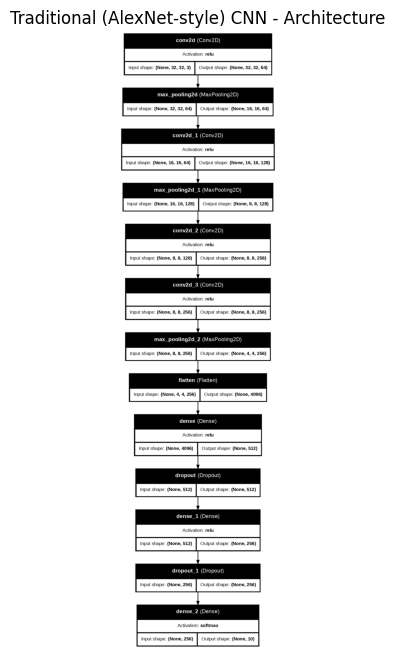

Diagram saved to: traditional_cnn_architecture.png


In [12]:
def plot_architecture_diagram(model, title, filename):
    """
    Render a visual architecture diagram for a Keras Sequential model.
    Tries Keras' built-in plot_model (requires pydot + graphviz). If that
    isn't available in the current environment, falls back to a manual
    layer-by-layer block diagram drawn with matplotlib, so a diagram is
    always produced either way.
    """
    try:
        from tensorflow.keras.utils import plot_model
        plot_model(
            model, to_file=filename, show_shapes=True, show_layer_names=True,
            show_layer_activations=True, dpi=110, expand_nested=False
        )
        img = plt.imread(filename)
        plt.figure(figsize=(6, max(8, len(model.layers) * 0.6)))
        plt.imshow(img)
        plt.axis('off')
        plt.title(title)
        plt.show()
        print(f"Diagram saved to: {filename}")
        return
    except Exception as e:
        print(f"[plot_model unavailable ({e}); drawing a manual block diagram instead]")

    # ---- Fallback: manual block diagram ----
    layers_info = []
    for layer in model.layers:
        try:
            out_shape = layer.output_shape
        except Exception:
            out_shape = getattr(layer, 'output.shape', '?')
        layers_info.append((layer.__class__.__name__, layer.name, out_shape))

    n = len(layers_info)
    fig, ax = plt.subplots(figsize=(7, max(6, n * 0.55)))
    box_h = 0.8
    for i, (cls, name, shape) in enumerate(layers_info):
        y = n - i
        ax.add_patch(plt.Rectangle((0, y - box_h / 2), 6, box_h,
                                    edgecolor='black', facecolor='#cfe2f3'))
        ax.text(0.15, y, f"{cls}  ({name})", va='center', fontsize=9)
        ax.text(4.4, y, f"{shape}", va='center', fontsize=8, color='dimgray')
        if i < n - 1:
            ax.annotate('', xy=(3, y - box_h / 2 - 0.08), xytext=(3, y - box_h / 2 + 0.02),
                         arrowprops=dict(arrowstyle='->'))
    ax.set_xlim(-0.2, 6.2)
    ax.set_ylim(0, n + 1)
    ax.axis('off')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=110, bbox_inches='tight')
    plt.show()
    print(f"Diagram saved to: {filename}")

plot_architecture_diagram(traditional_model, 'Traditional (AlexNet-style) CNN - Architecture', 'traditional_cnn_architecture.png')

## Step 5 | Train the Traditional CNN

In [13]:
BATCH_SIZE = 64
EPOCHS_PART_A = 30   # fixed epoch budget - reused as-is in Part B

traditional_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history_a = traditional_model.fit(
    X_train, y_train_cat,
    validation_data=(X_valid, y_valid_cat),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_PART_A,
    verbose=1
)
traditional_train_time = time.time() - start_time

print(f'\nTraditional CNN training time: {traditional_train_time:.1f} seconds '
      f'({traditional_train_time/60:.2f} minutes) over {EPOCHS_PART_A} epochs')

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.3362 - loss: 1.7664 - val_accuracy: 0.4526 - val_loss: 1.5099
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5203 - loss: 1.3342 - val_accuracy: 0.5792 - val_loss: 1.1680
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6016 - loss: 1.1344 - val_accuracy: 0.6190 - val_loss: 1.1068
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6557 - loss: 0.9898 - val_accuracy: 0.6410 - val_loss: 1.0709
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6961 - loss: 0.8758 - val_accuracy: 0.6808 - val_loss: 0.9395
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7285 - loss: 0.7833 - val_accuracy: 0.6676 - val_loss: 1.0072
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7540 - loss: 0.7126 - val_accuracy: 0.7074 - val_loss: 0.8708
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7809 - loss: 0.6374 - val_acc

## Step 6 | Learning Curves

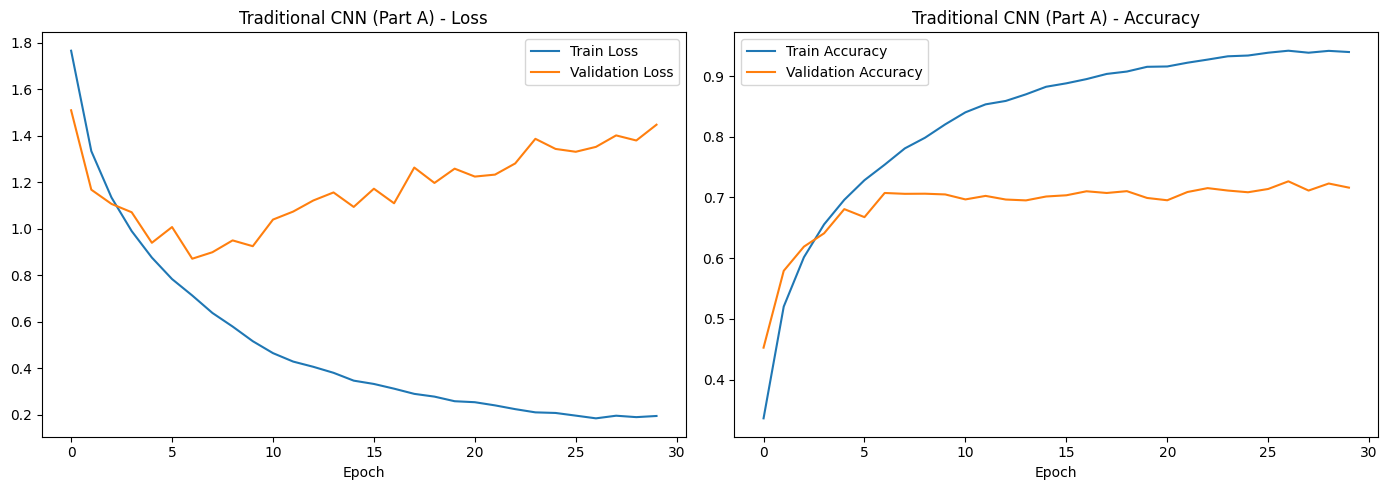

In [14]:
def plot_learning_curves(history, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title(f'{title_prefix} - Loss')
    axes[0].set_xlabel('Epoch'); axes[0].legend()

    axes[1].plot(history.history['accuracy'], label='Train Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[1].set_title(f'{title_prefix} - Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_learning_curves(history_a, 'Traditional CNN (Part A)')

## Step 7 | Evaluate the Traditional CNN on Test Data

--- Traditional CNN (Part A): Test Set Results ---
Test Loss     : 1.6380
Test Accuracy : 0.7020
Precision(macro): 0.7043
Recall(macro)   : 0.7020
F1-score(macro) : 0.7004

              precision    recall  f1-score   support

    airplane       0.73      0.77      0.75      1000
  automobile       0.82      0.85      0.83      1000
        bird       0.67      0.52      0.58      1000
         cat       0.47      0.56      0.51      1000
        deer       0.67      0.57      0.62      1000
         dog       0.64      0.57      0.60      1000
        frog       0.68      0.80      0.74      1000
       horse       0.71      0.78      0.75      1000
        ship       0.84      0.81      0.83      1000
       truck       0.80      0.80      0.80      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



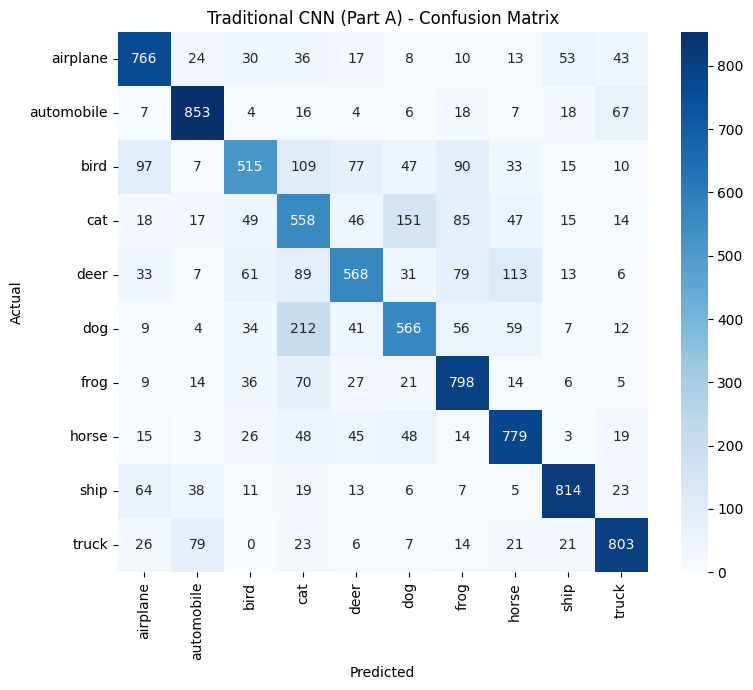

In [15]:
def full_evaluation(model, X_test, y_test_cat, y_test_int, class_names, model_name):
    test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = y_test_int.ravel()

    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

    print(f'--- {model_name}: Test Set Results ---')
    print(f'Test Loss     : {test_loss:.4f}')
    print(f'Test Accuracy : {test_acc:.4f}')
    print(f'Precision(macro): {precision:.4f}')
    print(f'Recall(macro)   : {recall:.4f}')
    print(f'F1-score(macro) : {f1:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return {
        'Model': model_name,
        'Test Accuracy': test_acc,
        'Test Loss': test_loss,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    }

traditional_results = full_evaluation(
    traditional_model, X_test, y_test_cat, y_test, class_names, 'Traditional CNN (Part A)'
)

traditional_results['Params'] = traditional_param_count
traditional_results['Training Time (s)'] = traditional_train_time
traditional_results['Epochs'] = EPOCHS_PART_A
traditional_results['Train Accuracy'] = history_a.history['accuracy'][-1]
traditional_results['Val Accuracy'] = history_a.history['val_accuracy'][-1]

In [16]:
print('Success threshold check (>= 70% test accuracy):')
if traditional_results['Test Accuracy'] >= 0.70:
    print(f"PASS - Traditional CNN reached {traditional_results['Test Accuracy']*100:.2f}% test accuracy.")
else:
    print(f"NOT MET - Traditional CNN reached only {traditional_results['Test Accuracy']*100:.2f}% "
          f"test accuracy (target: 70%). Consider more epochs or minor architecture tuning if this baseline "
          f"must hit the threshold before Part B.")

Success threshold check (>= 70% test accuracy):
PASS - Traditional CNN reached 70.20% test accuracy.


# Part B: Customized CNN Model

**Objective:** Design and implement a customized CNN that **measurably improves** on the traditional model from Part A.

**Success threshold:** the custom CNN must beat the traditional CNN's test accuracy by a measurable margin (target **≥ 3 percentage points**), and the improvement must be justified by a clear architectural or training reason — not by random variation or extra training alone.

**Rules for a fair comparison (followed here):**
- Same fixed seed (`SEED = 42`) and the exact same train/validation/test split as Part A   (`X_train`, `X_valid`, `X_test` — no re-splitting).
- Same number of training epochs as Part A (`EPOCHS_PART_A = 30`), unless explicitly   justified otherwise.

## Step 1 | Data Augmentation (introduced only in Part B)

In [17]:
data_generator = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
data_generator.fit(X_train)

## Step 2 | Define the Customized CNN Architecture

In [18]:
def build_customized_cnn(input_shape=(32, 32, 3), num_classes=10, weight_decay=1e-4):
    model = Sequential(name='Customized_CNN')

    # Block 1: 64 filters, 3x3 x2, BatchNorm, light dropout
    model.add(Conv2D(64, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=l2(weight_decay), input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))          # 32x32 -> 16x16
    model.add(Dropout(0.2))

    # Block 2: 128 filters, 3x3 x2
    model.add(Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))          # 16x16 -> 8x8
    model.add(Dropout(0.3))

    # Block 3: 256 filters, 3x3 x2
    model.add(Conv2D(256, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)))
    model.add(BatchNormalization())
    model.add(Conv2D(256, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))          # 8x8 -> 4x4
    model.add(Dropout(0.4))

    # Block 4 (ADDITIONAL vs Part A): 256 filters, no further pooling (keeps 4x4)
    model.add(Conv2D(256, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    # Fully connected head
    model.add(Flatten())
    model.add(Dense(512, activation='relu', kernel_regularizer=l2(weight_decay)))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    return model

customized_model = build_customized_cnn()
customized_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Customized_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,844,938 (14.67 MB)

 Trainable params: 3,841,610 (14.65 MB)

 Non-trainable params: 3,328 (13.00 KB)

In [19]:
customized_param_count = customized_model.count_params()
print('Total parameters (Customized CNN):', f'{customized_param_count:,}')
print('Total parameters (Traditional CNN):', f'{traditional_param_count:,}')
print(f"Parameter increase: {customized_param_count - traditional_param_count:,} "
      f"({(customized_param_count/traditional_param_count - 1)*100:.1f}% more)")

Total parameters (Customized CNN): 3,844,938
Total parameters (Traditional CNN): 3,326,602
Parameter increase: 518,336 (15.6% more)


## Step 2b | Architecture Diagram (Customized CNN)

Same diagram utility as Part A, applied to the customized model, so both diagrams use an identical visual style for a fair side-by-side comparison.

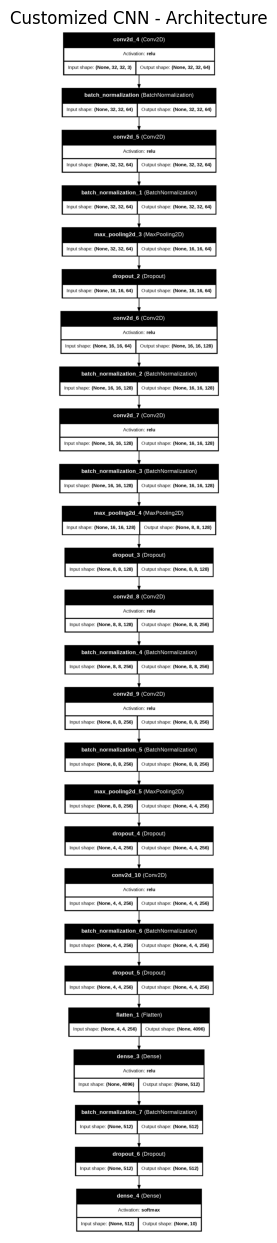

Diagram saved to: customized_cnn_architecture.png


In [20]:
plot_architecture_diagram(customized_model, 'Customized CNN - Architecture', 'customized_cnn_architecture.png')

## Step 3 | Train the Customized CNN

In [21]:
EPOCHS_PART_B = EPOCHS_PART_A  # same epoch budget as Part A - no extra-training justification needed

customized_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

start_time = time.time()
history_b = customized_model.fit(
    data_generator.flow(X_train, y_train_cat, batch_size=BATCH_SIZE, seed=SEED),
    validation_data=(X_valid, y_valid_cat),
    epochs=EPOCHS_PART_B,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    callbacks=[reduce_lr],
    verbose=1
)
customized_train_time = time.time() - start_time

print(f'\nCustomized CNN training time: {customized_train_time:.1f} seconds '
      f'({customized_train_time/60:.2f} minutes) over {EPOCHS_PART_B} epochs')

Epoch 1/30
703/703 ━━━━━━━━━━━━━━━━━━━━ 58s 63ms/step - accuracy: 0.3669 - loss: 2.1929 - val_accuracy: 0.4354 - val_loss: 2.4283 - learning_rate: 5.0000e-04
Epoch 2/30
  1/703 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.4219 - loss: 1.8714

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


703/703 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4219 - loss: 1.8714 - val_accuracy: 0.4364 - val_loss: 2.4395 - learning_rate: 5.0000e-04
Epoch 3/30
703/703 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.5304 - loss: 1.5372 - val_accuracy: 0.5724 - val_loss: 1.4537 - learning_rate: 5.0000e-04
Epoch 4/30
703/703 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5938 - loss: 1.3315 - val_accuracy: 0.5718 - val_loss: 1.4501 - learning_rate: 5.0000e-04
Epoch 5/30
703/703 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.6207 - loss: 1.2831 - val_accuracy: 0.6366 - val_loss: 1.2993 - learning_rate: 5.0000e-04
Epoch 6/30
703/703 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6875 - loss: 1.1361 - val_accuracy: 0.6140 - val_loss: 1.3886 - learning_rate: 5.0000e-04
Epoch 7/30
703/703 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.6759 - loss: 1.1469 - val_accuracy: 0.7188 - val_loss: 1.0231 - learning_rate: 5.0000e-04
Epoch 8/30
703/703 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.625

## Step 4 | Learning Curves

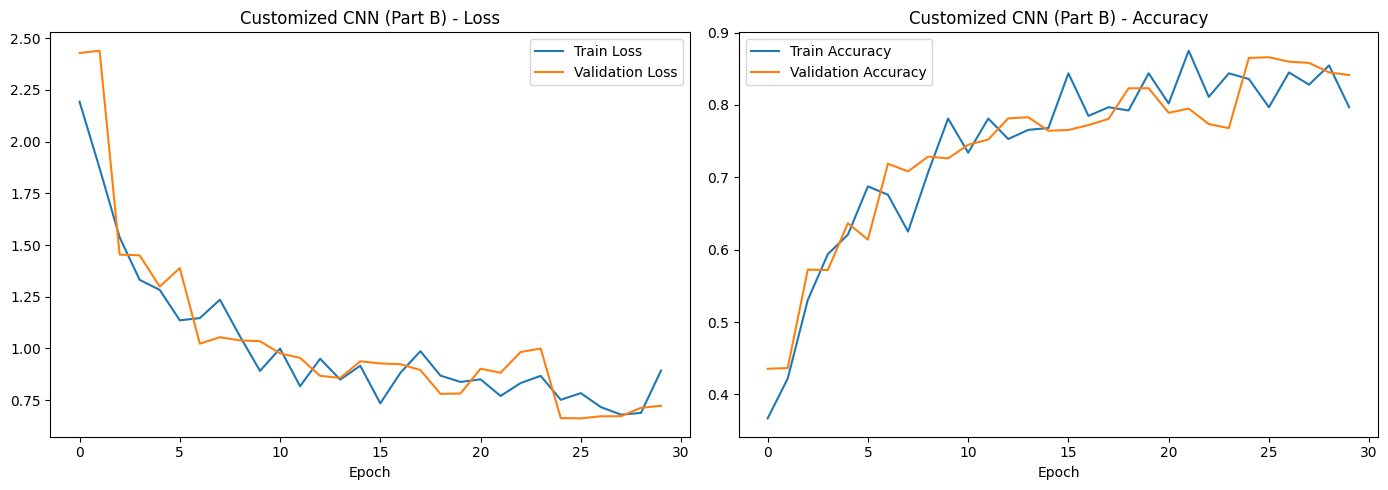

In [22]:
plot_learning_curves(history_b, 'Customized CNN (Part B)')

## Step 5 | Evaluate the Customized CNN on Test Data

--- Customized CNN (Part B): Test Set Results ---
Test Loss     : 0.7509
Test Accuracy : 0.8319
Precision(macro): 0.8472
Recall(macro)   : 0.8319
F1-score(macro) : 0.8313

              precision    recall  f1-score   support

    airplane       0.91      0.80      0.85      1000
  automobile       0.92      0.92      0.92      1000
        bird       0.81      0.80      0.81      1000
         cat       0.67      0.76      0.71      1000
        deer       0.88      0.81      0.84      1000
         dog       0.93      0.58      0.72      1000
        frog       0.70      0.97      0.81      1000
       horse       0.93      0.86      0.89      1000
        ship       0.95      0.86      0.90      1000
       truck       0.78      0.96      0.86      1000

    accuracy                           0.83     10000
   macro avg       0.85      0.83      0.83     10000
weighted avg       0.85      0.83      0.83     10000



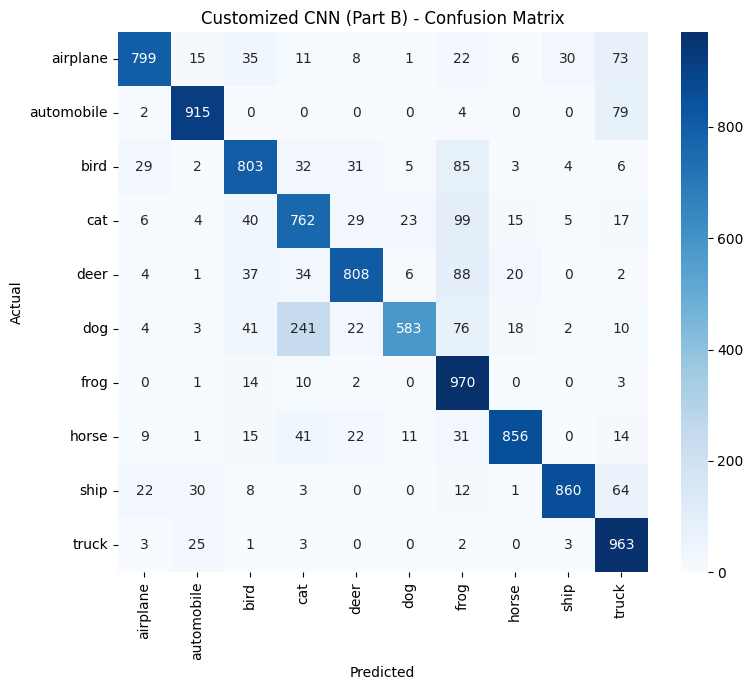

In [23]:
customized_results = full_evaluation(
    customized_model, X_test, y_test_cat, y_test, class_names, 'Customized CNN (Part B)'
)

customized_results['Params'] = customized_param_count
customized_results['Training Time (s)'] = customized_train_time
customized_results['Epochs'] = EPOCHS_PART_B
customized_results['Train Accuracy'] = history_b.history['accuracy'][-1]
customized_results['Val Accuracy'] = history_b.history['val_accuracy'][-1]

## Step 6 | Final Comparison: Traditional CNN vs Customized CNN

In [24]:
import pandas as pd

comparison_df = pd.DataFrame([traditional_results, customized_results]).set_index('Model')
comparison_df = comparison_df[['Test Accuracy', 'Precision', 'Recall', 'F1-score',
                                'Train Accuracy', 'Val Accuracy',
                                'Params', 'Training Time (s)', 'Epochs']]
print(comparison_df.round(4))

                          Test Accuracy  Precision  Recall  F1-score  \
Model                                                                  
Traditional CNN (Part A)         0.7020     0.7043  0.7020    0.7004   
Customized CNN (Part B)          0.8319     0.8472  0.8319    0.8313   

                          Train Accuracy  Val Accuracy   Params  \
Model                                                             
Traditional CNN (Part A)          0.9396        0.7162  3326602   
Customized CNN (Part B)           0.7969        0.8414  3844938   

                          Training Time (s)  Epochs  
Model                                                
Traditional CNN (Part A)           286.4534      30  
Customized CNN (Part B)            526.8884      30  


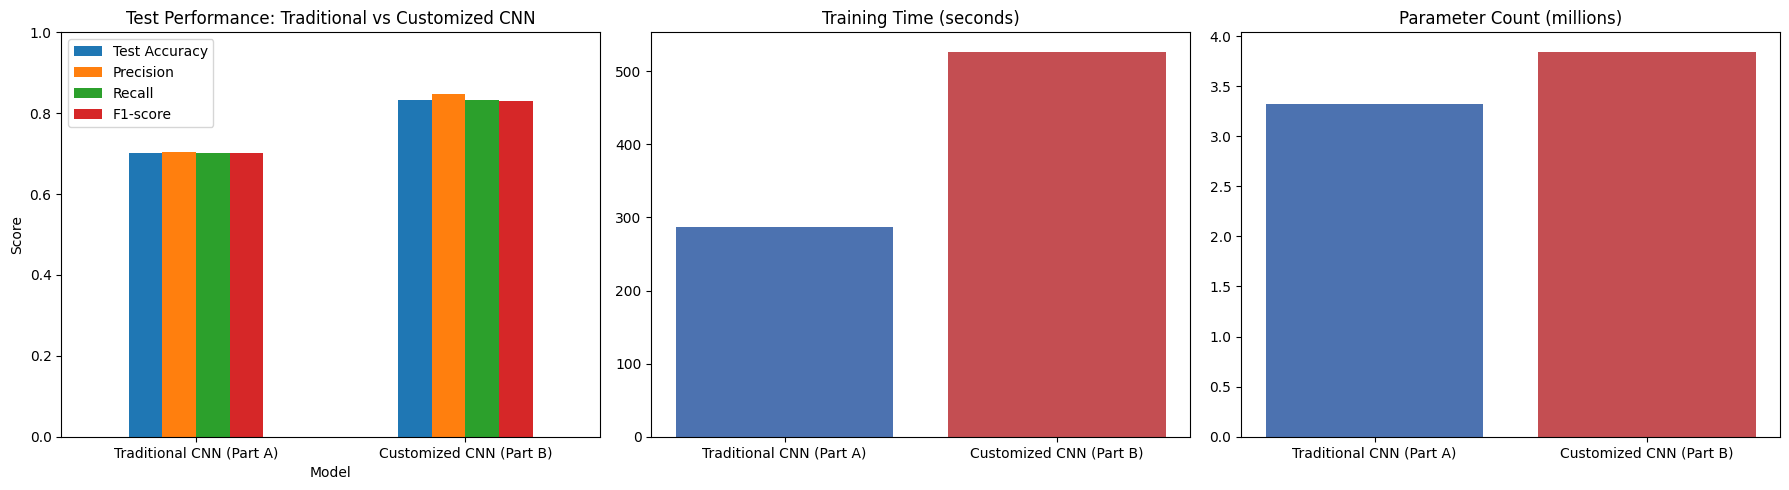

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_plot = comparison_df[['Test Accuracy', 'Precision', 'Recall', 'F1-score']]
metrics_plot.plot(kind='bar', ax=axes[0])
axes[0].set_title('Test Performance: Traditional vs Customized CNN')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=0)

axes[1].bar(comparison_df.index, comparison_df['Training Time (s)'], color=['#4C72B0', '#C44E52'])
axes[1].set_title('Training Time (seconds)')
axes[1].tick_params(axis='x', rotation=0)

params_millions = comparison_df['Params'] / 1e6
axes[2].bar(comparison_df.index, params_millions, color=['#4C72B0', '#C44E52'])
axes[2].set_title('Parameter Count (millions)')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


### Accuracy-vs-Cost Trade-off and Success Threshold Check

In [26]:
acc_gain_pp = (customized_results['Test Accuracy'] - traditional_results['Test Accuracy']) * 100
param_increase_pct = (customized_results['Params'] / traditional_results['Params'] - 1) * 100
time_increase_pct = (customized_results['Training Time (s)'] / traditional_results['Training Time (s)'] - 1) * 100

print(f"Traditional CNN test accuracy : {traditional_results['Test Accuracy']*100:.2f}%")
print(f"Customized CNN test accuracy  : {customized_results['Test Accuracy']*100:.2f}%")
print(f"Accuracy gain                 : {acc_gain_pp:+.2f} percentage points")
print(f"Parameter count change        : {param_increase_pct:+.1f}%")
print(f"Training time change          : {time_increase_pct:+.1f}%")
print()

if acc_gain_pp >= 3.0:
    print(f"PASS - Customized CNN beat the traditional baseline by {acc_gain_pp:.2f} points "
          f"(>= 3.0 point target), for a {param_increase_pct:.1f}% increase in parameters and "
          f"{time_increase_pct:.1f}% more training time.")
    if acc_gain_pp / max(param_increase_pct, 1e-6) > 0.02:
        print("The accuracy gain appears to justify the added size/time cost.")
    else:
        print("The gain clears the threshold, but review whether the added size/time cost "
              "is worth it for your deployment constraints.")
else:
    print(f"NOT MET - Customized CNN improved by only {acc_gain_pp:.2f} points "
          f"(< 3.0 point target). Revisit the architectural changes in Step 2 (e.g. strengthen "
          f"augmentation, tune dropout/learning rate further) rather than simply adding more epochs.")

Traditional CNN test accuracy : 70.20%
Customized CNN test accuracy  : 83.19%
Accuracy gain                 : +12.99 percentage points
Parameter count change        : +15.6%
Training time change          : +83.9%

PASS - Customized CNN beat the traditional baseline by 12.99 points (>= 3.0 point target), for a 15.6% increase in parameters and 83.9% more training time.
The accuracy gain appears to justify the added size/time cost.
